# Analiza 3: Poređenje tempa dva vozača (Mann-Whitney U test)

**Hipoteza:** Verstappen (VER, #1) i Norris (NOR, #4) - najbliži rivali za titulu u sezoni
2024 - imaju statistički različitu raspodelu vremena kruga u ovoj trci.

**Metod:** Neparametarski Mann-Whitney U test (`scipy.stats.mannwhitneyu`) nad "čistim"
vremenima kruga (bez in/out krugova i bez ekstremnih vrednosti kao safety car krugovi).
Neparametarski test je izabran jer ne pretpostavljamo normalnu raspodelu vremena kruga i
raspodela je osetljiva na retke velike odstupnike (npr. greške, saobraćaj).

**Kome je ovo bitno:** Analitičarima performansi i timovima - potvrđuje (ili obara) da je
razlika u tempu koju gledamo tokom trke realna razlika u brzini, a ne samo šum.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("F1Analysis").getOrCreate()


DATA_DIR = "../data/processed"


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/07 00:08:55 WARN Utils: Your hostname, Ognjens-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.55 instead (on interface en0)
26/07/07 00:08:55 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/07 00:08:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
from pyspark.sql import functions as F

laps = spark.read.csv(f"{DATA_DIR}/laps.csv", header=True, inferSchema=True)
drivers = spark.read.csv(f"{DATA_DIR}/drivers.csv", header=True, inferSchema=True)

DRIVER_A, DRIVER_B = 1, 4
drivers.filter(F.col("driver_number").isin([DRIVER_A, DRIVER_B])) \
       .select("driver_number", "full_name", "team_name").show()


+-------------+--------------+---------------+
|driver_number|     full_name|      team_name|
+-------------+--------------+---------------+
|            1|Max VERSTAPPEN|Red Bull Racing|
|            4|  Lando NORRIS|        McLaren|
+-------------+--------------+---------------+



In [3]:
laps_clean = laps.filter((F.col("is_pit_out_lap") == False) & F.col("lap_duration").isNotNull())

q_low, q_high = laps_clean.approxQuantile("lap_duration", [0.02, 0.98], 0.001)
laps_clean = laps_clean.filter((F.col("lap_duration") >= q_low) & (F.col("lap_duration") <= q_high))

a_times = laps_clean.filter(F.col("driver_number") == DRIVER_A).select("lap_duration").toPandas()["lap_duration"]
b_times = laps_clean.filter(F.col("driver_number") == DRIVER_B).select("lap_duration").toPandas()["lap_duration"]

print(f"Driver {DRIVER_A}: n={len(a_times)}, median={a_times.median():.3f}s")
print(f"Driver {DRIVER_B}: n={len(b_times)}, median={b_times.median():.3f}s")


Driver 1: n=61, median=70.288s
Driver 4: n=58, median=70.418s


In [4]:
from scipy import stats

u_stat, p_value = stats.mannwhitneyu(a_times, b_times, alternative="two-sided")
print(f"Mann-Whitney U: U = {u_stat:.1f}, p = {p_value:.4f}")


Mann-Whitney U: U = 1648.5, p = 0.5235


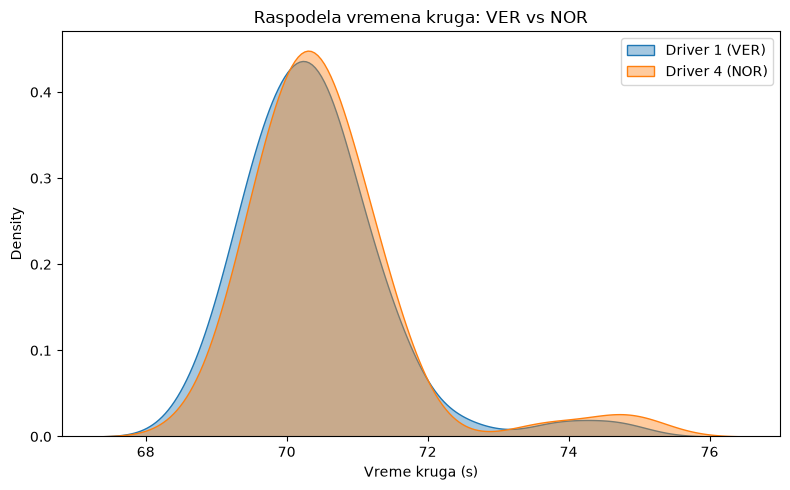

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(a_times, label=f"Driver {DRIVER_A} (VER)", fill=True, alpha=0.4, ax=ax)
sns.kdeplot(b_times, label=f"Driver {DRIVER_B} (NOR)", fill=True, alpha=0.4, ax=ax)
ax.set_xlabel("Vreme kruga (s)")
ax.set_title("Raspodela vremena kruga: VER vs NOR")
ax.legend()
plt.tight_layout()
plt.show()


**Zaključak:** U ovoj konkretnoj trci p-vrednost (≈0.52) je znatno iznad 0.05 - medijane
tempa VER-a (70.29s) i NOR-a (70.42s) su toliko blizu da test NE nalazi statistički značajnu
razliku. Drugim rečima, na ovoj stazi njih dvojica su bili suštinski podjednako brzi tokom
trke (razlika u konačnom plasmanu bi tad dolazila iz drugih faktora - starta, strategije,
grešaka - a ne iz sirove brzine bolida). Da je p-vrednost bila ispod 0.05, to bi značilo da je
razlika u tempu realna, a ne slučajna. Ovakav test se lako generalizuje na poređenje bilo koja
dva vozača/tima kroz sezonu (npr. za "teammate battle" analizu), a negativan rezultat (kao
ovde) je isto koristan nalaz - govori timu da tempo NIJE bio faktor te trke.

### Dopuna: telemetrijsko poređenje kroz jedan (isti) krug

Statistički test iznad kaže *da li* postoji razlika u tempu - ovaj deo pokazuje *gde na stazi*
ta razlika nastaje. Biramo krug 30 (čist krug za oba vozača, bez "in/out lap-a") i crtamo
brzinu/gas/kočnicu tokom tog kruga jedno preko drugog.

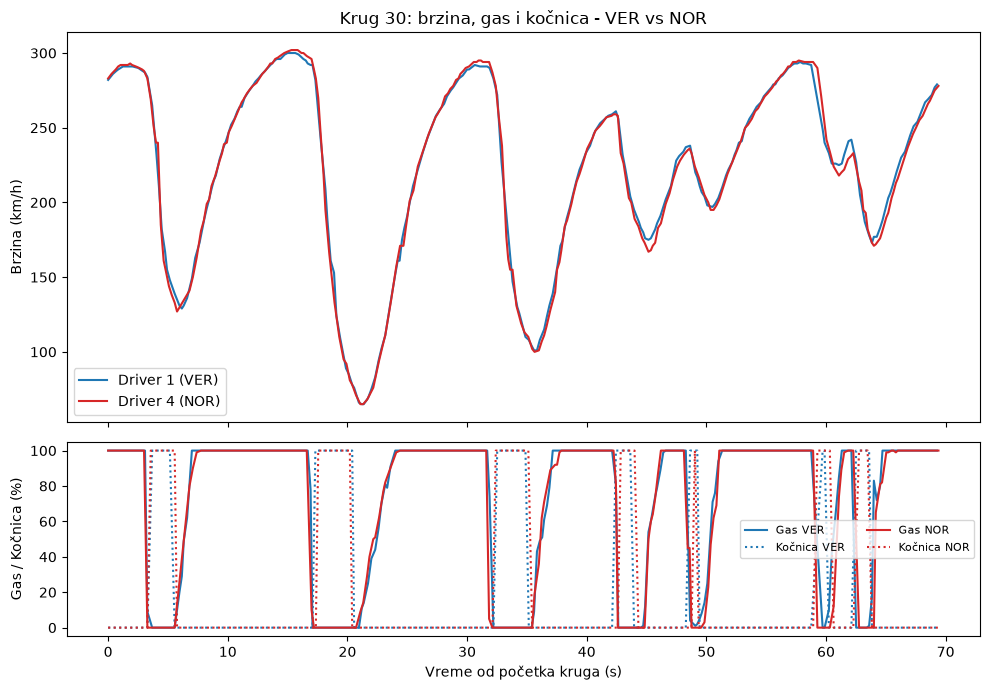

In [6]:
telemetry_a = spark.read.csv(f"{DATA_DIR}/driver_{DRIVER_A}_telemetry.csv", header=True, inferSchema=True)
telemetry_b = spark.read.csv(f"{DATA_DIR}/driver_{DRIVER_B}_telemetry.csv", header=True, inferSchema=True)

LAP = 30
lap_a = telemetry_a.filter(F.col("lap_number") == LAP).select("date", "speed", "throttle", "brake").toPandas()
lap_b = telemetry_b.filter(F.col("lap_number") == LAP).select("date", "speed", "throttle", "brake").toPandas()

lap_a["date"] = pd.to_datetime(lap_a["date"], format="ISO8601")
lap_b["date"] = pd.to_datetime(lap_b["date"], format="ISO8601")
lap_a["t"] = (lap_a["date"] - lap_a["date"].min()).dt.total_seconds()
lap_b["t"] = (lap_b["date"] - lap_b["date"].min()).dt.total_seconds()

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(lap_a["t"], lap_a["speed"], label=f"Driver {DRIVER_A} (VER)", color="#1f77b4")
axes[0].plot(lap_b["t"], lap_b["speed"], label=f"Driver {DRIVER_B} (NOR)", color="#d62728")
axes[0].set_ylabel("Brzina (km/h)")
axes[0].set_title(f"Krug {LAP}: brzina, gas i kočnica - VER vs NOR")
axes[0].legend()

axes[1].plot(lap_a["t"], lap_a["throttle"], color="#1f77b4", linestyle="-", label="Gas VER")
axes[1].plot(lap_a["t"], lap_a["brake"], color="#1f77b4", linestyle=":", label="Kočnica VER")
axes[1].plot(lap_b["t"], lap_b["throttle"], color="#d62728", linestyle="-", label="Gas NOR")
axes[1].plot(lap_b["t"], lap_b["brake"], color="#d62728", linestyle=":", label="Kočnica NOR")
axes[1].set_xlabel("Vreme od početka kruga (s)")
axes[1].set_ylabel("Gas / Kočnica (%)")
axes[1].legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


**Zaključak:** Tačke gde se linije brzine razdvajaju pokazuju konkretne dvoke/krivine u
kojima jedan vozač dobija ili gubi vreme - npr. ko koči kasnije, ko izlazi iz krivine sa više
gasa. Ovo pretvara apstraktnu statističku razliku iz gornjeg testa u konkretan, radnim
inženjerima koristan uvid o tome GDE na stazi tražiti vreme.